# Layer 3 (PFF): RQ2 against the analysts' better-option labels

PFF analysts watched every 2022 World Cup match and, when a player missed a clearly better option, recorded what it was (another pass, holding the ball, a carry, and so on) and, for a pass, which teammate. This is an expert-labelled version of the RQ2 question. `08_layer3_pff_link.ipynb` counted these labels; this notebook compares them with RQ2.

**Three questions.**

1. **Pass level.** Are passes the analysts labelled more often flagged by RQ2?
2. **Teammate level.** Is the teammate the analysts named the kind of option RQ2 looks for: inside the vision cone, a maximal-VAEP option, legitimate?
3. **Two scenarios for the poster.** One obvious missed forward pass, where the analysts and RQ2 agree, and one less obvious, flagged by RQ2 only and confirmed by the tracking.

**Why the rates will differ.** The analysts label only clear, coachable mistakes: about 0.3 percent of passes. RQ2 counts any visible, onside, completable forward option with a higher value, which is true for 38.9 percent of passes. So agreement here means pointing at the same passes and teammates, not matching rates.

**Inputs:** `pff_passes_all.pkl` and `pff_pass_links.pkl` (`08_layer3_pff_link.ipynb`), `pff_teammates_at_passes.pkl` (`09_layer3_pff_lstm_check.ipynb`), `rq3_reach_teammates.pkl` (`10_layer3_pff_reachability.ipynb`), `rq2_risk_context_pass_level.pkl` (`03_layer2_risk_and_context.ipynb`), `candidates_full.pkl` (`02_layer2_bias_analysis.ipynb`), and the cached StatsBomb events and freeze frames.

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")



import numpy as np
import pandas as pd
from mplsoccer import Pitch

RESULTS = Path('../data/results')
CACHE = Path('../data/statsbomb_cache')
NAVY, GREEN, GREY, LIGHT, DARK = '#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0', '#4B5563'
rng = np.random.default_rng(0)

pff_all = pd.read_pickle(RESULTS / 'pff_passes_all.pkl')
links = pd.read_pickle(RESULTS / 'pff_pass_links.pkl')
pl = pd.read_pickle(RESULTS / 'rq2_risk_context_pass_level.pkl')
tm = pd.read_pickle(RESULTS / 'pff_teammates_at_passes.pkl')
reach = pd.read_pickle(RESULTS / 'rq3_reach_teammates.pkl')
cands = pd.read_pickle(RESULTS / 'candidates_full.pkl')
match_map = pd.read_pickle(RESULTS / 'pff_match_map.pkl')
names = dict(zip(links['sb_player_id'], links['sb_player']))
print(len(pff_all), 'PFF passes and crosses,', len(links), 'linked to StatsBomb,', len(pl), 'passes analysed in RQ2')

69127 PFF passes and crosses, 61635 linked to StatsBomb, 98652 passes analysed in RQ2


## 1. The labelled passes

Which labels exist, how the labelled passes ended, and how many of them are among the passes RQ2 analyses. RQ2 only analyses completed passes with a 360 freeze frame, so labelled passes that failed drop out at this step.

In [2]:
pff_all['label'] = pff_all['better_option_type'].fillna('none')
print('better-option labels (P = a better pass to a named teammate; the other codes are other kinds of action):')
print(pff_all['label'].value_counts().to_string())

lab = links.merge(pff_all[['possession_event_id', 'label', 'better_option_player_id', 'outcome']],
                  left_on='pff_possession_event_id', right_on='possession_event_id', how='left')
lab = lab.merge(pl[['original_event_id', 'visible_orig', 'visible_ra', 'visible_strict', 'all_orig', 'minute', 'team']],
                left_on='sb_event_id', right_on='original_event_id', how='left')
lab['analysed'] = lab['original_event_id'].notna()
lab['label_pass'] = lab['label'].eq('P')

P_all = pff_all[pff_all['label'] == 'P']
print(f"\npass labels: {len(P_all)} in PFF, {lab['label_pass'].sum()} linked to StatsBomb, "
      f"{(lab['label_pass'] & lab['analysed']).sum()} among the passes analysed in RQ2")
print('\noutcome of labelled passes (C = complete):')
print(pd.DataFrame({'all labelled': P_all['outcome'].value_counts(),
                    'analysed in RQ2': lab[lab['label_pass'] & lab['analysed']]['outcome'].value_counts()}).fillna(0).astype(int))
print(f"\nshare complete among all PFF passes: {pff_all['outcome'].eq('C').mean():.1%}; among labelled passes: {P_all['outcome'].eq('C').mean():.1%}")

better-option labels (P = a better pass to a named teammate; the other codes are other kinds of action):
label
none    68791
P         209
H          59
L          30
B          14
C           9
O           9
S           6

pass labels: 209 in PFF, 196 linked to StatsBomb, 78 among the passes analysed in RQ2

outcome of labelled passes (C = complete):
         all labelled  analysed in RQ2
outcome                               
B                  20                0
C                  98               75
D                  85                2
O                   5                0
S                   1                1

share complete among all PFF passes: 81.4%; among labelled passes: 46.9%


**What this shows**

The analysts gave 336 better-option labels, 209 of them a better pass to a named teammate. 196 of those passes link to StatsBomb, but only 78 are among the passes analysed in RQ2.

**Most labelled passes failed, and RQ2 analyses completed passes.** Only 46.9 percent of labelled passes were completed, against 81.4 percent of all passes. Analysts mostly label a better option when the pass went wrong. RQ2 needs a completed pass with a 360 freeze frame, so most labels drop out, and 75 of the 78 that remain were completed.

## 2. Pass level: are labelled passes flagged more often by RQ2?

Among analysed passes, the RQ2 flag rate for passes with a pass label against all other passes. Four versions of the flag are shown: the main one (visible teammates), after risk adjustment, the strictest risk-adjusted version, and the omniscient version (all teammates). The interval for the difference resamples whole matches.

In [3]:
an = lab[lab['analysed']].copy()
flags = {'visible_orig': 'RQ2 flag (visible)', 'visible_ra': 'risk-adjusted', 'visible_strict': 'strict risk-adjusted',
         'all_orig': 'omniscient (all teammates)'}
rows = []
for col, name in flags.items():
    an[col] = an[col].astype(bool)
    per = an.groupby(['match_id', 'label_pass'])[col].agg(['sum', 'count']).unstack(fill_value=0)
    idx = rng.integers(0, len(per), size=(5000, len(per)))
    s = per.to_numpy()[idx].sum(axis=1)         # columns: sum False, sum True, count False, count True
    diff = s[:, 1] / np.maximum(s[:, 3], 1) - s[:, 0] / s[:, 2]
    yes, no = an.loc[an['label_pass'], col].mean(), an.loc[~an['label_pass'], col].mean()
    rows.append({'flag': name, 'labelled passes': 100 * yes, 'other passes': 100 * no, 'difference': 100 * (yes - no),
                 'ci_low': 100 * np.percentile(diff, 2.5), 'ci_high': 100 * np.percentile(diff, 97.5)})
pass_level = pd.DataFrame(rows).set_index('flag')
print(f"{an['label_pass'].sum()} labelled and {(~an['label_pass']).sum()} other analysed passes\n")
print(pass_level.round(1))

78 labelled and 35685 other analysed passes

                            labelled passes  other passes  difference  ci_low  \
flag                                                                            
RQ2 flag (visible)                     33.3          37.1        -3.8   -13.9   
risk-adjusted                          32.1          33.5        -1.4   -10.0   
strict risk-adjusted                   19.2          21.7        -2.4    -9.4   
omniscient (all teammates)             65.4          72.4        -7.0   -17.3   

                            ci_high  
flag                                 
RQ2 flag (visible)              6.6  
risk-adjusted                   8.4  
strict risk-adjusted            5.0  
omniscient (all teammates)      2.9  


**What this shows**

**At the pass level, RQ2 does not single out the passes the analysts labelled.** 33.3 percent of labelled passes are flagged, against 37.1 percent of other passes (difference -3.8 points, 95 percent CI -13.9 to +6.6). The same holds for every version of the flag. With only 78 labelled passes the interval is wide, but there is no sign that labelled passes are flagged more often.

This is less surprising than it sounds. RQ2 asks whether any better forward option existed, which is true for four passes in ten. The analysts mark rare, clear mistakes. The two questions overlap less than their wording suggests, and section 3 shows one concrete reason why.

## 3. Teammate level: what is special about the teammate the analysts named?

For each analysed labelled pass, the named teammate is found among the freeze-frame teammates through the PFF player match, and compared with the other freeze-frame teammates on the same pass:

- inside the StatsBomb vision cone;
- a maximal-VAEP option (target zone has higher xT than the passer's zone, and VAEP value higher than the pass played);
- legitimate (also visible, onside and xP at least 0.05), which is what RQ2 counts;
- offside by the freeze frame;
- the highest-valued option on the pass;
- would arrive by the PFF tracking check (`10_layer3_pff_reachability.ipynb`, ball at 12.5 m/s, aimed at the true position).

Because each pass contributes one named teammate and several others, the comparison is made within each pass (named minus the average of the others), and the interval resamples passes.

In [4]:
P = an[an['label_pass']][['sb_event_id', 'pff_possession_event_id', 'better_option_player_id', 'match_id']]
t = tm[tm['in_freeze_frame'] & tm['cand_index'].notna()].merge(
    P[['pff_possession_event_id', 'better_option_player_id']], on='pff_possession_event_id')
t['named'] = t['pff_player_id'].eq(t['better_option_player_id'])
found = t.groupby('pff_possession_event_id')['named'].any()
print(f"named teammate found among the freeze-frame teammates on {found.sum()} of {len(found)} passes")

c = cands[['visible', 'candidate_value', 'real_value', 'forward_progressive', 'legitimate_forward_progressive',
           'offside', 'xp_value', 'xt_origin', 'xt_target']]
t = t.drop(columns=['visible']).merge(c, left_on='cand_index', right_index=True, how='left')
t = t.merge(reach[['cand_index', 'arr_true_v12.5']], on='cand_index', how='left')
t = t[t['pff_possession_event_id'].isin(found[found].index)].copy()
t['in_cone'] = t['visible'].astype(float)
t['maximal_vaep'] = t['forward_progressive'].astype(float)
t['legitimate'] = t['legitimate_forward_progressive'].fillna(False).astype(float)
t['offside_'] = t['offside'].astype(float)
t['top_value'] = (t.groupby('pff_possession_event_id')['candidate_value'].rank(ascending=False, method='min') == 1).astype(float)
t['would_arrive'] = t['arr_true_v12.5'].astype(float)
t['xt_gain'] = t['xt_target'] - t['xt_origin']
measures = ['in_cone', 'maximal_vaep', 'legitimate', 'offside_', 'top_value', 'would_arrive', 'xt_gain']

g = t.groupby(['pff_possession_event_id', 'named'])[measures].mean().unstack('named')
rows = []
for m in measures:
    d = (g[(m, True)] - g[(m, False)]).dropna()
    idx = rng.integers(0, len(d), size=(5000, len(d)))
    bd = d.to_numpy()[idx].mean(axis=1)
    scale = 1 if m == 'xt_gain' else 100
    rows.append({'measure': m, 'named teammate': scale * g[(m, True)].mean(), 'others on the same pass': scale * g[(m, False)].mean(),
                 'difference': scale * d.mean(), 'ci_low': scale * np.percentile(bd, 2.5), 'ci_high': scale * np.percentile(bd, 97.5),
                 'passes': len(d)})
teammate_level = pd.DataFrame(rows).set_index('measure')
print('\npercentages, except xt_gain (xT units):')
print(teammate_level.round(3).to_string())
print(f"\nchance of the top value by picking a teammate at random: {(1 / t.groupby('pff_possession_event_id').size()).mean():.1%}")

named teammate found among the freeze-frame teammates on 71 of 78 passes

percentages, except xt_gain (xT units):
              named teammate  others on the same pass  difference  ci_low  ci_high  passes
measure                                                                                   
in_cone               59.155                   28.301      30.853  18.568   42.118      71
maximal_vaep          42.254                   29.911      12.342   2.025   22.649      71
legitimate            16.901                    9.577       7.324  -0.175   15.453      71
offside_              12.857                    2.765      10.092   2.911   18.143      70
top_value             21.127                   15.848       5.278  -5.546   16.816      71
would_arrive          57.746                   51.787       5.959  -6.182   17.534      71
xt_gain                0.006                    0.004       0.003  -0.000    0.006      71

chance of the top value by picking a teammate at random: 17.6%


**What this shows**

The named teammate was found among the freeze-frame teammates on 71 of the 78 passes.

**The analysts' better option is the kind of teammate RQ2 looks for.** Compared with the other teammates on the same pass, the named teammate is:

- inside the vision cone far more often: 59.2 against 28.3 percent (+30.9 points, CI +18.6 to +42.1);
- more often a maximal-VAEP option: 42.3 against 29.9 percent (+12.3, CI +2.0 to +22.6);
- somewhat more often a legitimate RQ2 option: 16.9 against 9.6 percent (+7.3, CI -0.2 to +15.5).

The first point supports the perception-aware approach: when experts say "he should have passed to X", X is usually a teammate the passer could see.

**Where the two disagree: runs.** The named teammate is offside in the freeze frame 12.9 percent of the time, against 2.8 percent for other teammates (+10.1, CI +2.9 to +18.1). The analysts often have in mind a through ball timed to a teammate's run, played into space ahead of them. RQ2 values a pass to where the teammate stands at the moment of the pass, so it cannot represent that option. This is a limit of freeze-frame counterfactuals and worth stating in the write-up.

**VAEP does not rank the analysts' choice as the best.** The named teammate is the highest-valued option on 21.1 percent of passes, close to the 17.6 percent expected from picking a teammate at random. The tracking check says a pass to their current position would arrive for 57.7 percent, against 51.8 percent for the others (not distinguishable).

## 4. Two scenarios for the poster

Both scenarios need a clearly forward option, so the missed teammate must be at least 10 yards ahead of the passer (section 5 of `02_layer2_bias_analysis.ipynb` shows that some maximal-VAEP options are not ahead of the passer at all).

**Obvious:** a pass the analysts labelled, where the teammate they named is also a legitimate maximal-VAEP option in RQ2: inside the cone, onside, completable, and worth more than the pass played. Experts and model agree.

**Less obvious:** a pass the analysts did not label, which RQ2 flags, where the flagged option is also at least 10 yards beyond where the real pass went, and the tracking says a pass to that teammate would have arrived. Only the model sees the missed option, and the tracking confirms it was on.

Each list is ranked by the VAEP gain of the missed option over the pass that was played. The top pass of each list is drawn below; any other row can be drawn with `draw_scenario`.

In [5]:
teams = dict(zip(match_map['match_id'].astype(str), match_map['teams']))
pmap = pd.read_pickle(RESULTS / 'pff_player_map.pkl')
sb_of_pff = dict(zip(pmap['pff_player_id'], pmap['sb_player_id']))

info = an.set_index('sb_event_id')[['match_id', 'minute', 'team', 'sb_player']]
opt = tm[tm['in_freeze_frame'] & tm['cand_index'].notna()][['original_event_id', 'cand_index', 'pff_player_id']]
opt = opt.merge(cands[['candidate_value', 'real_value', 'legitimate_forward_progressive', 'xp_value', 'cand_x', 'cand_y',
                       'passer_location', 'real_end_x']], left_on='cand_index', right_index=True)
opt = opt.merge(reach[['cand_index', 'arr_true_v12.5']], on='cand_index', how='left')
opt['legit'] = opt['legitimate_forward_progressive'].astype('boolean').fillna(False).astype(bool)
opt['would_arrive'] = opt['arr_true_v12.5'].astype('boolean').fillna(False).astype(bool)
opt['ahead_yd'] = opt['cand_x'] - opt['passer_location'].str[0]
opt['beyond_real_yd'] = opt['cand_x'] - opt['real_end_x']
opt['vaep_gain'] = opt['candidate_value'] - opt['real_value']
opt['option_player'] = opt['pff_player_id'].map(sb_of_pff).map(names)
opt = opt[opt['legit'] & (opt['ahead_yd'] >= 10)]


def table(o):
    o = o.sort_values('vaep_gain', ascending=False).drop_duplicates('original_event_id').join(info, on='original_event_id')
    o['match'] = o['match_id'].astype(str).map(teams)
    return o[['original_event_id', 'match', 'minute', 'team', 'sb_player', 'option_player', 'ahead_yd', 'vaep_gain',
              'xp_value', 'would_arrive', 'cand_index']].reset_index(drop=True)


named_of = an[an['label_pass']].set_index('sb_event_id')['better_option_player_id']
obvious = table(opt[opt['original_event_id'].isin(named_of.index)
                    & opt['pff_player_id'].eq(opt['original_event_id'].map(named_of))])
unlabelled = an.loc[~an['label_pass'] & an['visible_orig'], 'sb_event_id']
less_obvious = table(opt[opt['original_event_id'].isin(unlabelled) & opt['would_arrive'] & (opt['beyond_real_yd'] >= 10)])
pd.set_option('display.width', 200)
show = ['match', 'minute', 'team', 'sb_player', 'option_player', 'ahead_yd', 'vaep_gain', 'xp_value', 'would_arrive']
print(f"obvious: {len(obvious)} labelled passes where the named teammate is a legitimate maximal-VAEP option at least 10 yd ahead")
print(obvious[show].round(4).to_string())
print(f"\nless obvious: {len(less_obvious)} unlabelled RQ2-flagged passes with a tracking-confirmed forward option (top 8 by VAEP gain)")
print(less_obvious[show].head(8).round(4).to_string())

obvious: 8 labelled passes where the named teammate is a legitimate maximal-VAEP option at least 10 yd ahead
                   match  minute       team                 sb_player                       option_player  ahead_yd  vaep_gain  xp_value  would_arrive
0  South Korea v Uruguay    43.0    Uruguay  Rodrigo Bentancur Colmán  Federico Santiago Valverde Dipetta   21.2293     0.0060    0.6806         False
1       France v Morocco    85.0    Morocco            Sofyan Amrabat               Abdessamad Ezzalzouli   17.6502     0.0049    0.8488         False
2     Argentina v Poland     5.0  Argentina       Alexis Mac Allister                      Julián Álvarez   18.2543     0.0020    0.5636         False
3       Brazil v Croatia    34.0    Croatia               Luka Modrić                          Borna Sosa   17.5678     0.0020    0.7121         False
4      Brazil v Cameroon    76.0     Brazil     Daniel Alves da Silva    Pedro Guilherme Abreu dos Santos   16.7028     0.0015    0.5256

saved ..\data\results\figures\rq2_scenario_obvious.png


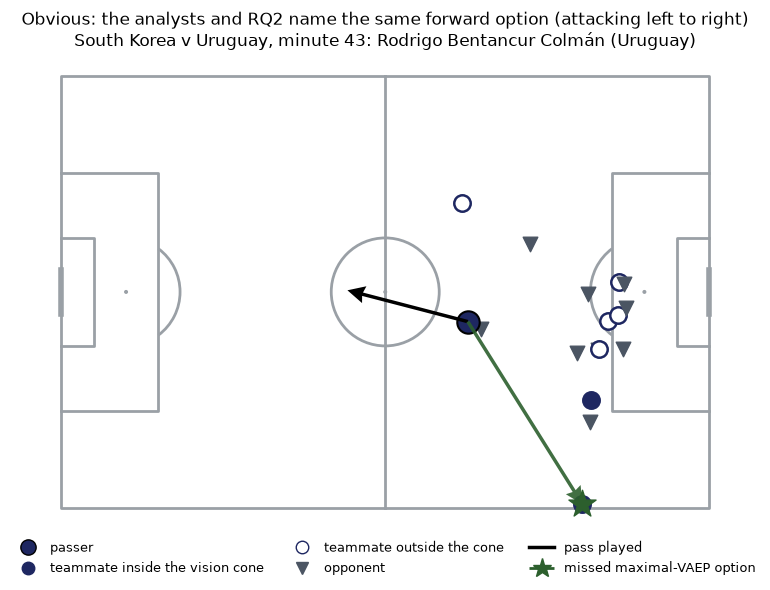

saved ..\data\results\figures\rq2_scenario_less_obvious.png


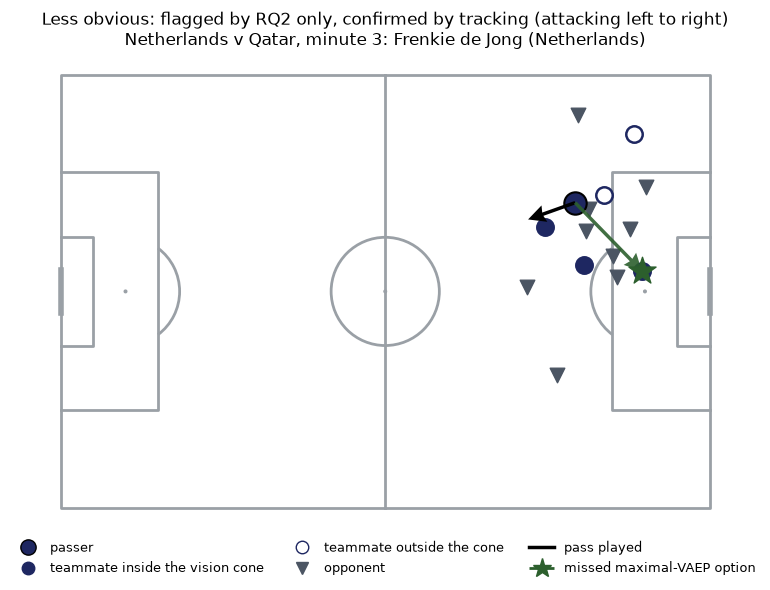

In [6]:
_events, _frames = {}, {}


def draw_scenario(row, title, fname=None):
    mid = str(info.loc[row['original_event_id'], 'match_id'])
    if mid not in _events:
        _events[mid] = pd.read_pickle(CACHE / f'events_{mid}.pkl')
        _frames[mid] = pd.read_pickle(CACHE / f'frames_{mid}.pkl')
    ev = _events[mid].set_index('id').loc[row['original_event_id']]
    fr = _frames[mid][_frames[mid]['id'] == row['original_event_id']]
    cw = cands[cands['original_event_id'] == row['original_event_id']]

    # candidates may be stored mirrored; bring the frame into the same coordinates
    start = np.array(ev['location'], dtype=float)
    end = np.array(ev['pass_end_location'], dtype=float)
    mirrored = bool(cw['mirrored'].iloc[0])
    flip = (lambda p: np.array([120 - p[0], 80 - p[1]])) if mirrored else (lambda p: np.asarray(p, dtype=float))
    start, end = flip(start), flip(end)

    pitch = Pitch(pitch_type='statsbomb', line_color='#9AA0A6', pitch_color='white')
    fig, ax = pitch.draw(figsize=(9, 6))
    for _, p in fr.iterrows():
        xy = flip(p['location'])
        if p['actor']:
            continue
        if p['teammate']:
            d = np.hypot(cw['cand_x'] - xy[0], cw['cand_y'] - xy[1])
            vis = bool(cw.loc[d.idxmin(), 'visible']) if len(cw) and d.min() < 1.5 else False
            ax.scatter(*xy, s=140, color=NAVY if vis else 'white', edgecolor=NAVY, lw=1.8, zorder=3)
        else:
            ax.scatter(*xy, s=110, color=DARK, marker='v', zorder=3)
    ax.scatter(*start, s=260, color=NAVY, edgecolor='black', lw=1.5, zorder=4)
    pitch.arrows(start[0], start[1], end[0], end[1], ax=ax, color='black', width=2.5, headwidth=5, zorder=5)
    tx, ty = cands.loc[row['cand_index'], 'cand_x'], cands.loc[row['cand_index'], 'cand_y']
    pitch.arrows(start[0], start[1], tx, ty, ax=ax, color=GREEN, width=2.5, headwidth=5, ls='--', alpha=0.9, zorder=5)
    ax.scatter(tx, ty, s=420, color=GREEN, marker='*', zorder=6)
    handles = [plt.Line2D([], [], marker='o', ls='', color=NAVY, markeredgecolor='black', markersize=11, label='passer'),
               plt.Line2D([], [], marker='o', ls='', color=NAVY, markersize=9, label='teammate inside the vision cone'),
               plt.Line2D([], [], marker='o', ls='', color='white', markeredgecolor=NAVY, markersize=9, label='teammate outside the cone'),
               plt.Line2D([], [], marker='v', ls='', color=DARK, markersize=9, label='opponent'),
               plt.Line2D([], [], color='black', lw=2.5, label='pass played'),
               plt.Line2D([], [], marker='*', color=GREEN, ls='--', lw=2, markersize=14, label='missed maximal-VAEP option')]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False, fontsize=9)
    ax.set_title(f"{title} (attacking left to right)\n{row['match']}, minute {int(row['minute'])}: {row['sb_player']} ({row['team']})", fontsize=12)
    if fname:
        save_fig(fig, fname)
    plt.show()


draw_scenario(obvious.iloc[0], 'Obvious: the analysts and RQ2 name the same forward option', 'rq2_scenario_obvious.png')
draw_scenario(less_obvious.iloc[0], 'Less obvious: flagged by RQ2 only, confirmed by tracking', 'rq2_scenario_less_obvious.png')

**What this shows**

**Obvious scenario.** 8 labelled passes have a named teammate who is also a legitimate maximal-VAEP option at least 10 yards ahead of the passer. The top one: South Korea v Uruguay, minute 43. Rodrigo Bentancur plays the ball back while Federico Valverde is on the right touchline, 21 yards further forward and inside Bentancur's cone (xP 0.68). Another strong choice from the list is France v Morocco, minute 85 (Sofyan Amrabat, the semi-final).

For 6 of the 8, the tracking says a pass to the teammate's current position would not arrive. This fits section 3: the analysts often picture a pass into the space ahead of a run.

**Less obvious scenario.** 2342 passes are flagged by RQ2 only, with a forward option that is at least 10 yards beyond where the real pass went and that the tracking confirms would arrive. The top one: Netherlands v Qatar, minute 3. Frenkie de Jong plays backward while Davy Klaassen is in the box, 12 yards ahead, and the tracking says a pass would have reached him (xP 0.61, VAEP gain 0.037, about six times the gain in the obvious scenario).

A suggestion for the poster: the second row of the less obvious list is also from South Korea v Uruguay (minute 71, Valverde to Vecino, xP 0.88). Using minutes 43 and 71 of the same match would give both scenarios the same teams and setting.

## 5. Save

In [7]:
pd.to_pickle({'pass_level': pass_level, 'teammate_level': teammate_level,
              'obvious': obvious, 'less_obvious': less_obvious}, RESULTS / 'pff_better_options.pkl')
print('saved pff_better_options.pkl')

saved pff_better_options.pkl


## Summary

**How RQ2 compares with the PFF analysts' better-option labels (2022 World Cup).**

- **The labels are rare and mostly on failed passes.** 209 passes carry a better-pass label; only 46.9 percent of them were completed, so just 78 are among the completed passes RQ2 analyses.
- **Pass level: no agreement.** Labelled passes are not flagged by RQ2 more often than other passes (33.3 against 37.1 percent, CI for the difference -13.9 to +6.6). RQ2 measures how often a better option existed; the analysts mark clear mistakes.
- **Teammate level: agreement on what a good option looks like.** The analysts' named teammate is inside the passer's cone twice as often as other teammates (59.2 against 28.3 percent) and more often a maximal-VAEP option (42.3 against 29.9 percent). Experts point at visible, higher-value teammates, as the framework does.
- **The main difference is runs.** Named teammates are offside in the freeze frame far more often (12.9 against 2.8 percent): the analysts picture through balls into space, which a freeze-frame counterfactual cannot value.

**Two poster scenarios** are drawn and saved: an obvious one where the analysts and RQ2 name the same forward option (South Korea v Uruguay, minute 43), and a less obvious one flagged only by RQ2 and confirmed by the tracking (Netherlands v Qatar, minute 3). The full candidate lists are in `pff_better_options.pkl`.

**For the write-up.** This is a partial external validation: experts and the model agree on what kind of teammate is a better option, not on which passes count as mistakes. The sample is small (78 passes, 71 named teammates), so these comparisons have wide intervals.

Saved: `pff_better_options.pkl`, `figures/rq2_scenario_obvious.png`, `figures/rq2_scenario_less_obvious.png`.